# Small crystalline dataset

> Georgios Varnavides | Oct 21 2025  
>
> Sample: thin strontium titanate (STO)  
> Sampling conditions: Nyquist  
> Imaging conditions: 20 mrad, in-focus, defocus, coma, defocus + coma  

In [1]:
import abtem
import ase
import numpy as np
import matplotlib.pyplot as plt

## STO Unitcell

We'll make an ASE Atoms object using Materials Project entry [mp-5229](https://next-gen.materialsproject.org/materials/mp-5229). Note this uses Wyckoff Positions and Spacegroups, but you can also export the CIF/POSCAR file if you prefer.

In [42]:
# from ase.build import fcc111, fcc100
# lc=4.08
# unit_cell = fcc111('Au', size=(2, 2, 6), a=lc, vacuum=0.1, orthogonal=False)
# unit_cell_3 = fcc100('Au', size=(2, 2, 6), a=lc, vacuum=0.00001)
# nanoparticle_1 = abtem.orthogonalize_cell(unit_cell) * (16,8,1)
# nanoparticle_2 = abtem.orthogonalize_cell(unit_cell) * (16,8,1)
# nanoparticle_3 = abtem.orthogonalize_cell(unit_cell_3) * (16,8,1)
# nanoparticle_2.rotate(25,'z')
# # Get positions for each nanoparticle
# pos1 = nanoparticle_1.get_positions()
# pos2 = nanoparticle_2.get_positions()
# pos3 = nanoparticle_3.get_positions()

# # Create boolean masks based on x, y conditions
# mask1 = (pos1[:, 0] < 10) & (pos1[:, 1] > 20) & (pos1[:, 1] <50)  # x < 10 AND y < 15
# mask2 = (pos2[:, 0] > 10) & (pos2[:, 1] > 20) & (pos2[:, 1] <50) & (pos2[:,0] <40) # x > 10 AND y > 15
# mask3 = (pos3[:, 1] < 20) & (pos3[:,0] <40)

# # Apply masks using index arrays
# filtered_1 = nanoparticle_1[np.where(mask1)[0]]
# filtered_2 = nanoparticle_2[np.where(mask2)[0]]
# filtered_3 = nanoparticle_3[np.where(mask3)[0]]

# # Combine the two filtered structures
# supported_nanoparticle = filtered_1 + filtered_2 + filtered_3
# supported_nanoparticle.center(vacuum=10)
# x_length = supported_nanoparticle.cell[0, 0]
# y_length = supported_nanoparticle.cell[1, 1]
# max_length = max(x_length, y_length)

# if x_length < max_length:
#     extra_vacuum = (max_length - x_length) / 2
#     supported_nanoparticle.center(axis=0, vacuum=10 + extra_vacuum)

# if y_length < max_length:
#     extra_vacuum = (max_length - y_length) / 2
#     supported_nanoparticle.center(axis=1, vacuum=10 + extra_vacuum)
# fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
# abtem.show_atoms(
#     supported_nanoparticle,
#     ax=ax1,
#     title="Supported nanoparticle beam view",
#     merge=0.5,
#     scale=1,
# )
# abtem.show_atoms(
#     supported_nanoparticle,
#     ax=ax2,
#     plane="xz",
#     scale=1,
#     title="Supported nanoparticle side view",
#     merge=0.5,
# )
# abtem.show_atoms(
#     supported_nanoparticle,
#     ax=ax3,
#     plane="yz",
#     scale=1,
#     title="Supported nanoparticle side view",
#     merge=0.5,
# )
# fig.tight_layout();

length cell x 5.769991334482229
69.79739818016618 71.12460054134128


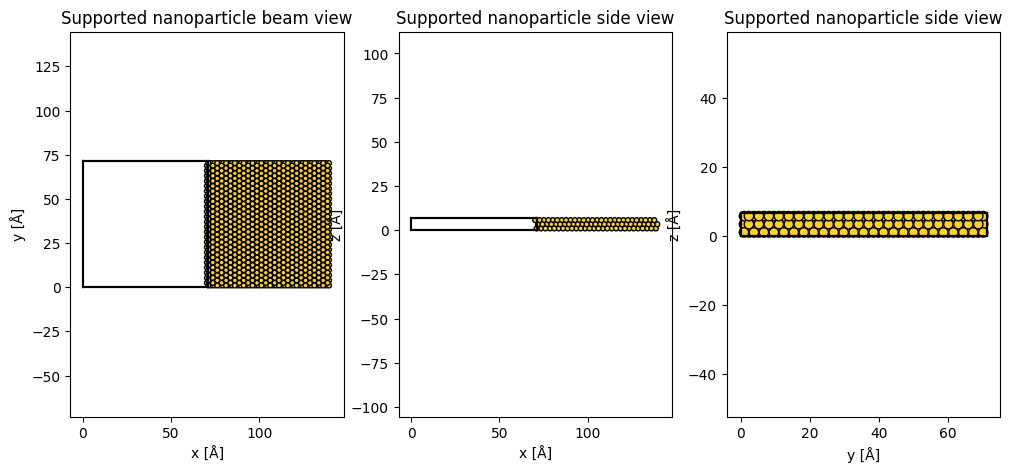

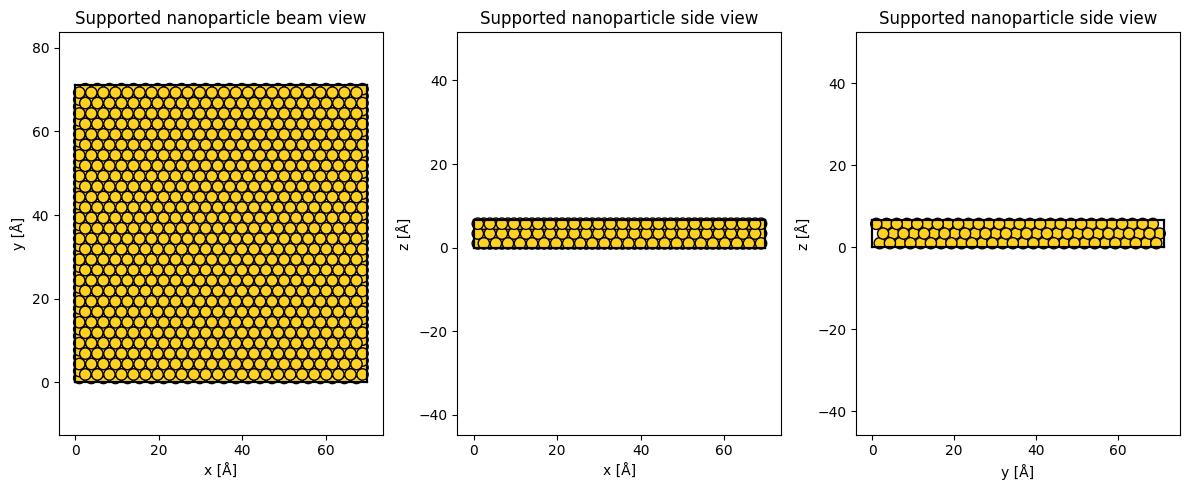

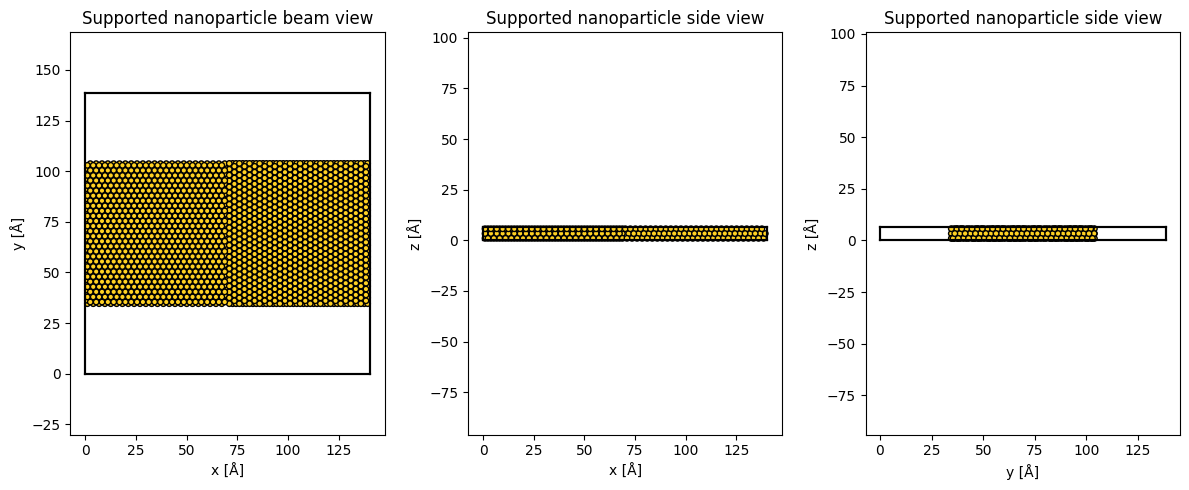

In [24]:
from ase.build import fcc111, fcc100
lc=4.08
unit_cell = fcc111('Au', size=(2, 2, 3), a=lc, vacuum=0.1, orthogonal=False)
x_reps = 12
y_reps = 7
nanoparticle_1 = abtem.orthogonalize_cell(unit_cell) * (x_reps, y_reps, 1)
nanoparticle_2 = abtem.orthogonalize_cell(unit_cell) * (x_reps * 4, y_reps * 4, 1)
nanoparticle_2.rotate(30,'z')
# Get positions for each nanoparticle
pos1 = nanoparticle_1.get_positions()
pos2 = nanoparticle_2.get_positions()
print(f'length cell x {abtem.orthogonalize_cell(unit_cell).cell[0,0]}')
x_length_cell = abtem.orthogonalize_cell(unit_cell).cell[0, 0]
y_length_cell = abtem.orthogonalize_cell(unit_cell).cell[1, 1]
mask = (pos2[:, 0] > 0) & (pos2[:, 0] < x_reps * x_length_cell) & (pos2[:, 1] > 50) & (pos2[:, 1] < (50 + y_reps * y_length_cell))

nanoparticle_2 = nanoparticle_2[np.where(mask)[0]]

nanoparticle_2.center(vacuum=1)
nanoparticle_2.translate([x_reps * x_length_cell, 0, 0])
nanoparticle_1.center(vacuum=1)
nanoparticle = nanoparticle_1 + nanoparticle_2
nanoparticle.center(vacuum=1)

x_length = nanoparticle.cell[0, 0]
y_length = nanoparticle.cell[1, 1]
max_length = max(x_length, y_length)

if x_length < max_length:
    extra_vacuum = (max_length - x_length) / 2
    nanoparticle.center(axis=0, vacuum=0.0001 + extra_vacuum)

if y_length < max_length:
    extra_vacuum = (max_length - y_length) / 2
    nanoparticle.center(axis=1, vacuum=0.0001 + extra_vacuum)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
abtem.show_atoms(
    nanoparticle_2,
    ax=ax1,
    title="Supported nanoparticle beam view",
    merge=0.5,
    scale=1,
)
abtem.show_atoms(
    nanoparticle_2,
    ax=ax2,
    plane="xz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.5,
)
abtem.show_atoms(
    nanoparticle_2,
    ax=ax3,
    plane="yz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.5,
)


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
abtem.show_atoms(
    nanoparticle_1,
    ax=ax1,
    title="Supported nanoparticle beam view",
    merge=0.5,
    scale=1,
)
abtem.show_atoms(
    nanoparticle_1,
    ax=ax2,
    plane="xz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.5,
)
abtem.show_atoms(
    nanoparticle_1,
    ax=ax3,
    plane="yz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.5,
)
fig.tight_layout();


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
abtem.show_atoms(
    nanoparticle,
    ax=ax1,
    title="Supported nanoparticle beam view",
    merge=0.5,
    scale=1,
)
abtem.show_atoms(
    nanoparticle,
    ax=ax2,
    plane="xz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.5,
)
abtem.show_atoms(
    nanoparticle,
    ax=ax3,
    plane="yz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.5,
)
fig.tight_layout();

x_length = nanoparticle_1.cell[0, 0]
y_length = nanoparticle_1.cell[1, 1]
print(x_length, y_length)

## Potential 

We build the numeric representation of the atomic potentials.

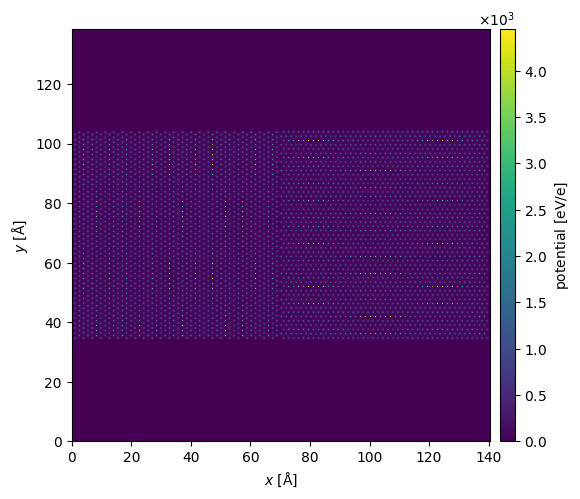

In [ ]:
potential = abtem.Potential(
    nanoparticle,
    sampling=lc/64,
    slice_thickness= lc/8,
    device='cpu',
).build(
    lazy=False
)

potential.show(
    cbar=True
);

## Probe

We use a converged probe with a few different aberrations.

tasks:   0%|          | 0/2 [00:00<?, ?it/s]

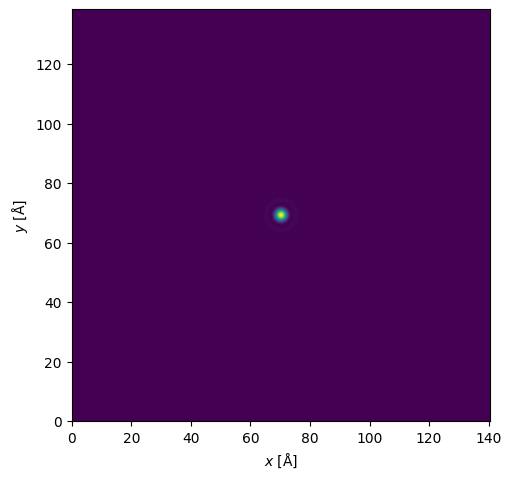

In [ ]:
energy = 10e3 # eV
semiangle_cutoff = 20 # mrad
import cupy as cp
cp.cuda.Device(1).use()

defocus_magnitude= 0
coma_magnitude = 0

aberrations = {
    "C10":defocus_magnitude,
    "C21":coma_magnitude,
    "phi21":-0.8,
}

# 2x2 probes ensemble
probes = abtem.Probe(
    energy=energy,
    semiangle_cutoff=semiangle_cutoff,
    aberrations=aberrations,
    device='cpu',
).match_grid(
    potential
)

probes.show(
    explode=True
)

## Simulations

In [35]:
grid_scan_Nyquist = abtem.GridScan(
    start = (x_length_cell * (x_reps-2), x_length_cell * (x_reps-2)),
    end = (x_length_cell * (x_reps+2), x_length_cell * (x_reps+2)),
    gpts=(24,24)
)

detector = abtem.PixelatedDetector(
    max_angle=None
)

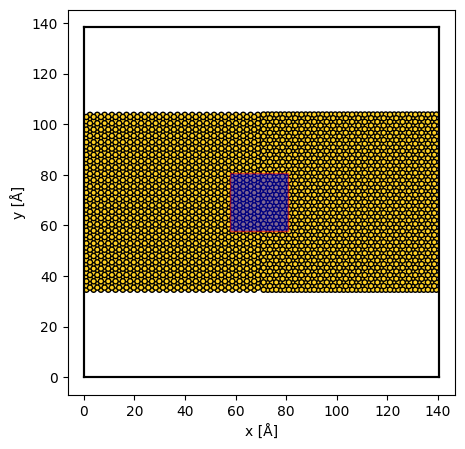

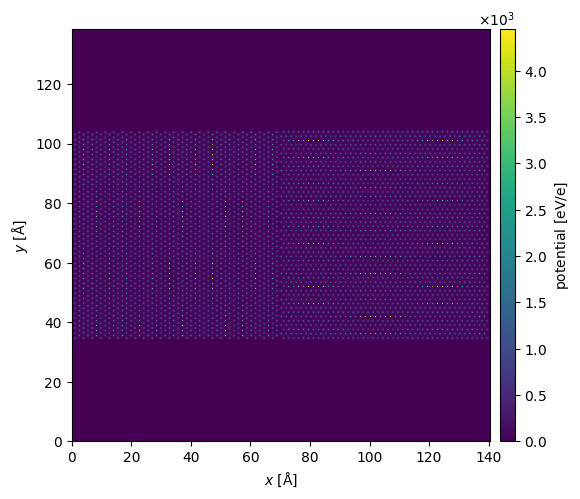

In [37]:
#| label: app:detectors_scansa
fig,ax = plt.subplots(figsize=(5,5))
abtem.show_atoms(
    nanoparticle,
    ax=ax
)
grid_scan_Nyquist.add_to_plot(ax,alpha=0.5,facecolor='b')

potential.show(
    cbar=True,
);

In [38]:
measurements = probes.scan(
    potential,
    grid_scan_Nyquist,
    detector,
    max_batch=128,
).compute(
).crop(
    gpts=(512,512)
)

tasks:   0%|          | 0/11 [00:00<?, ?it/s]

## Save Multidimensional Dataset
Temporary fix, until abTEM supports zarr>3.

In [39]:
import quantem as em

sampling = [
    grid_scan_Nyquist.sampling[0],
    grid_scan_Nyquist.sampling[1],
    measurements.angular_sampling[0],
    measurements.angular_sampling[1],
]

units = ["A","A","mrad","mrad"]
# units = ["A","A","A^-1","A^-1"]


dataset = em.core.datastructures.Dataset.from_array(
    measurements.to_cpu().array,
    sampling=sampling,
    units=units,
)

dataset.save("/home/wdekleijne/git-repos/willem-playground/data/gold_20mrad_10kev_Nyquist_plane_3_layer_fcc_2_facet_plane_4_unitcell_512x512.zip",mode='o')

In [40]:
def add_poisson_noise(
    dataset,
    electrons_per_area,
):
    if electrons_per_area == np.inf:
        return dataset
    electrons_per_probe = electrons_per_area * dataset.sampling[:2].prod()
    
    dataset_noisy = dataset.copy()
    dataset_noisy.array = np.random.poisson(dataset.array * electrons_per_probe)
    return dataset_noisy

In [41]:
dose = 10e6
noisy_dataset = add_poisson_noise(
            dataset,
            dose
        )
noisy_dataset.save(f"/home/wdekleijne/git-repos/willem-playground/data/gold_20mrad_10kev_{dose:.0e}-dose_Nyquist_plane_3_layer_fcc_2_facet_plane_4_unitcell_512x512.zip",mode='o')